### Imports et configuration

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random

%matplotlib inline

### Chargement des données

In [4]:
def load_metadata_and_counts(dataset_dir: str) -> pd.DataFrame:
    """Lit les fichiers labels YOLO pour compter les insectes par image."""
    base_path = Path(dataset_dir)
    images_dir = base_path / "images"
    labels_dir = base_path / "labels"
    
    data = []
    
    for img_path in images_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
            
        jour = img_path.name[:8]
        label_path = labels_dir / img_path.with_suffix(".txt").name
        
        insect_count = 0
        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                insect_count = len(lines)
                
        data.append({
            "image_name": img_path.name,
            "image_path": str(img_path),
            "jour": jour,
            "insect_count": insect_count
        })
        
    return pd.DataFrame(data)

# Chargement depuis le sous-dossier de 'data'
DATASET_DIR = "../data/merged_filtered_dataset" 

print("Analyse des fichiers et comptage des insectes en cours...")
df = load_metadata_and_counts(DATASET_DIR)

# Afficher les 5 premières lignes pour vérifier interactivement
df.head()

Analyse des fichiers et comptage des insectes en cours...


,image_name,image_path,jour,insect_count
0,20221006_09-03-49-024129_raw_jpg.rf.4df65bba71...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
1,20221006_09-11-26-908410_raw_jpg.rf.d17c0ef063...,..\data\merged_filtered_dataset\images\2022100...,20221006,0
2,20221006_09-14-31-840309_raw_jpg.rf.28d2caeab7...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
3,20221006_09-14-34-972005_raw_jpg.rf.5a5d09316b...,..\data\merged_filtered_dataset\images\2022100...,20221006,1
4,20221006_09-14-44-434197_raw_jpg.rf.b0129cf391...,..\data\merged_filtered_dataset\images\2022100...,20221006,1


### Séparation des données (ajustement / test)

#### Choix fait de séparer les jeux de données par jours complets pour éviter toute fuite de données et s'assurer que l'algorithme utilisé est paramétré sur des images d'ajustement uniquement.

In [10]:
# Définition stricte des ensembles d'ajustement et de test
jours_ajustement = ['20221006', '20221007', '20221012', '20221017']
jours_test = ['20221018', '20221019', '20221020']

# Séparation du DataFrame
df_ajustement = df[df['jour'].isin(jours_ajustement)].copy()
df_test = df[df['jour'].isin(jours_test)].copy()

print(f"Images pour l'ajustement : {len(df_ajustement)}")
print(f"Images pour le test : {len(df_test)}")

Images pour l'ajustement : 702
Images pour le test : 399


### Implémentation d'un Background Subtractor (MOG2)

In [6]:
def apply_mog2_chronological_tuned(df: pd.DataFrame, day: str, 
                                   history: int = 15, 
                                   var_threshold: float = 100, 
                                   learning_rate: float = 0.05):
    """
    Applique MOG2 de manière strictement chronologique.
    - var_threshold : Baisse ce chiffre si l'algo rate des insectes (augmente la sensibilité).
                      Monte-le s'il détecte trop de bruit/ombres.
    - learning_rate : Vitesse d'adaptation au soleil (0 = figé, 1 = oublie tout à chaque image).

    Principe de MOG2 : analyse l'évolution de chaque pixels d'une série d'image au fil du temps pour séparer le décor fixe des objets en mouvement dessus.
    """

    df_day = df[df['jour'] == day].sort_values("image_name")
    
    # Initialisation avec les paramètres ajustables
    backSub = cv2.createBackgroundSubtractorMOG2(history=history, 
                                                 varThreshold=var_threshold, 
                                                 detectShadows=True)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    
    results = []
    
    # Passage unique et chronologique
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Le learning_rate est constant ici, permettant une adaptation fluide
        fg_mask_raw = backSub.apply(img_blur, learningRate=learning_rate)
        
        # Suppression des ombres
        _, fg_mask_no_shadows = cv2.threshold(fg_mask_raw, 200, 255, cv2.THRESH_BINARY)
        
        # Nettoyage
        fg_mask_clean = cv2.morphologyEx(fg_mask_no_shadows, cv2.MORPH_OPEN, kernel)
        
        results.append({
            'image_name': row['image_name'],
            'original': img,
            'mask_raw': fg_mask_raw,
            'mask_clean': fg_mask_clean
        })
        
    return results

### Visualisation des masques créés par le MOG2 sur des images des jours d'ajustement


TRAITEMENT DE LA JOURNÉE : 20221006


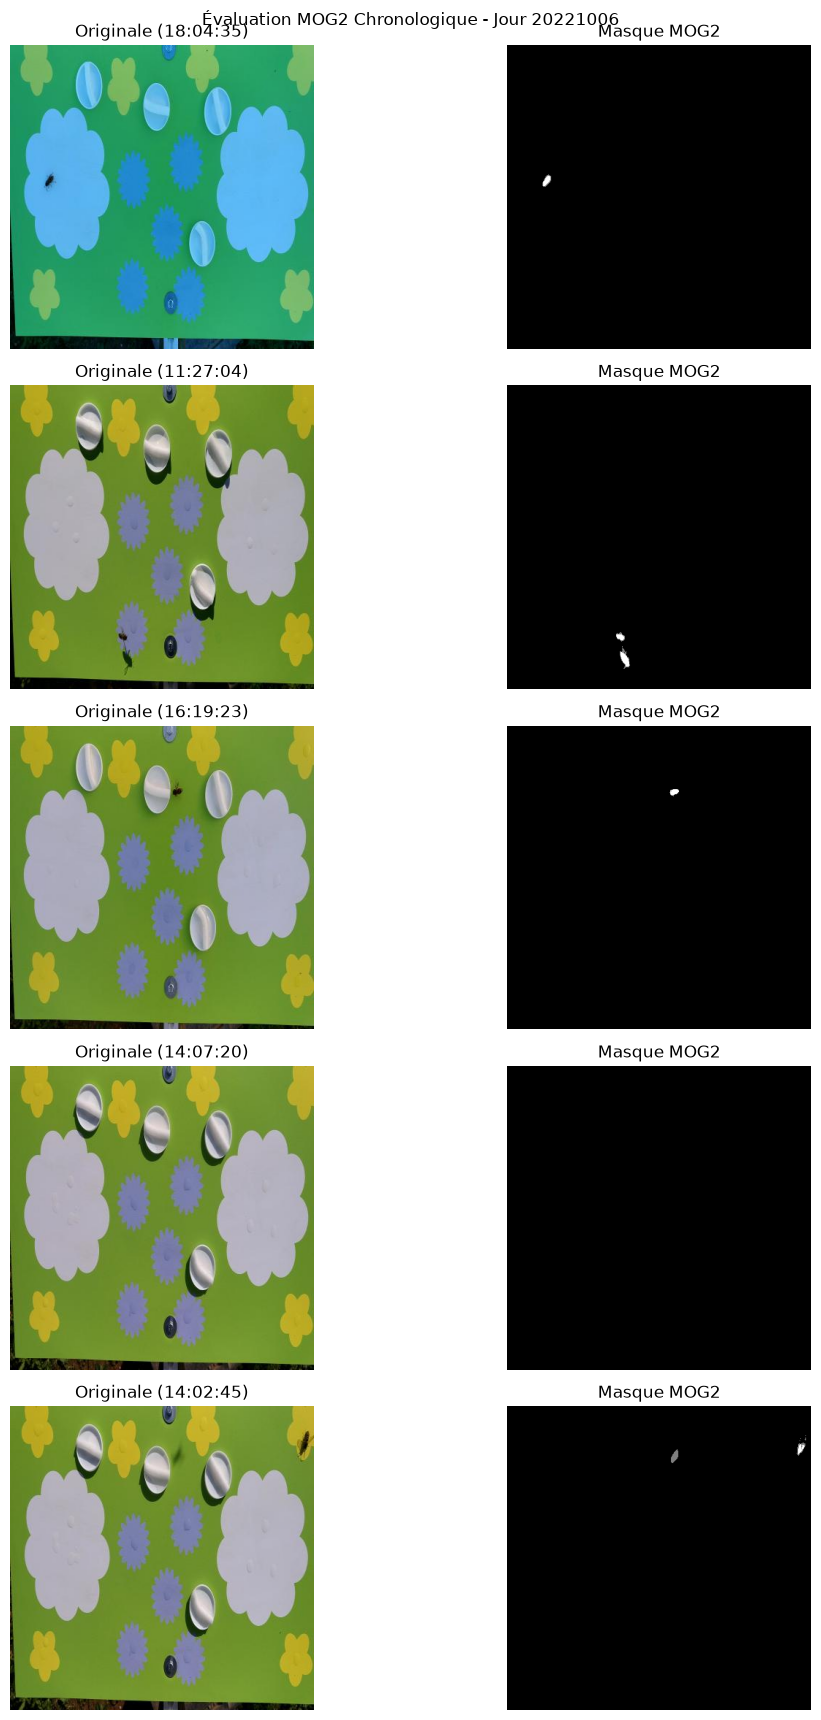


TRAITEMENT DE LA JOURNÉE : 20221007


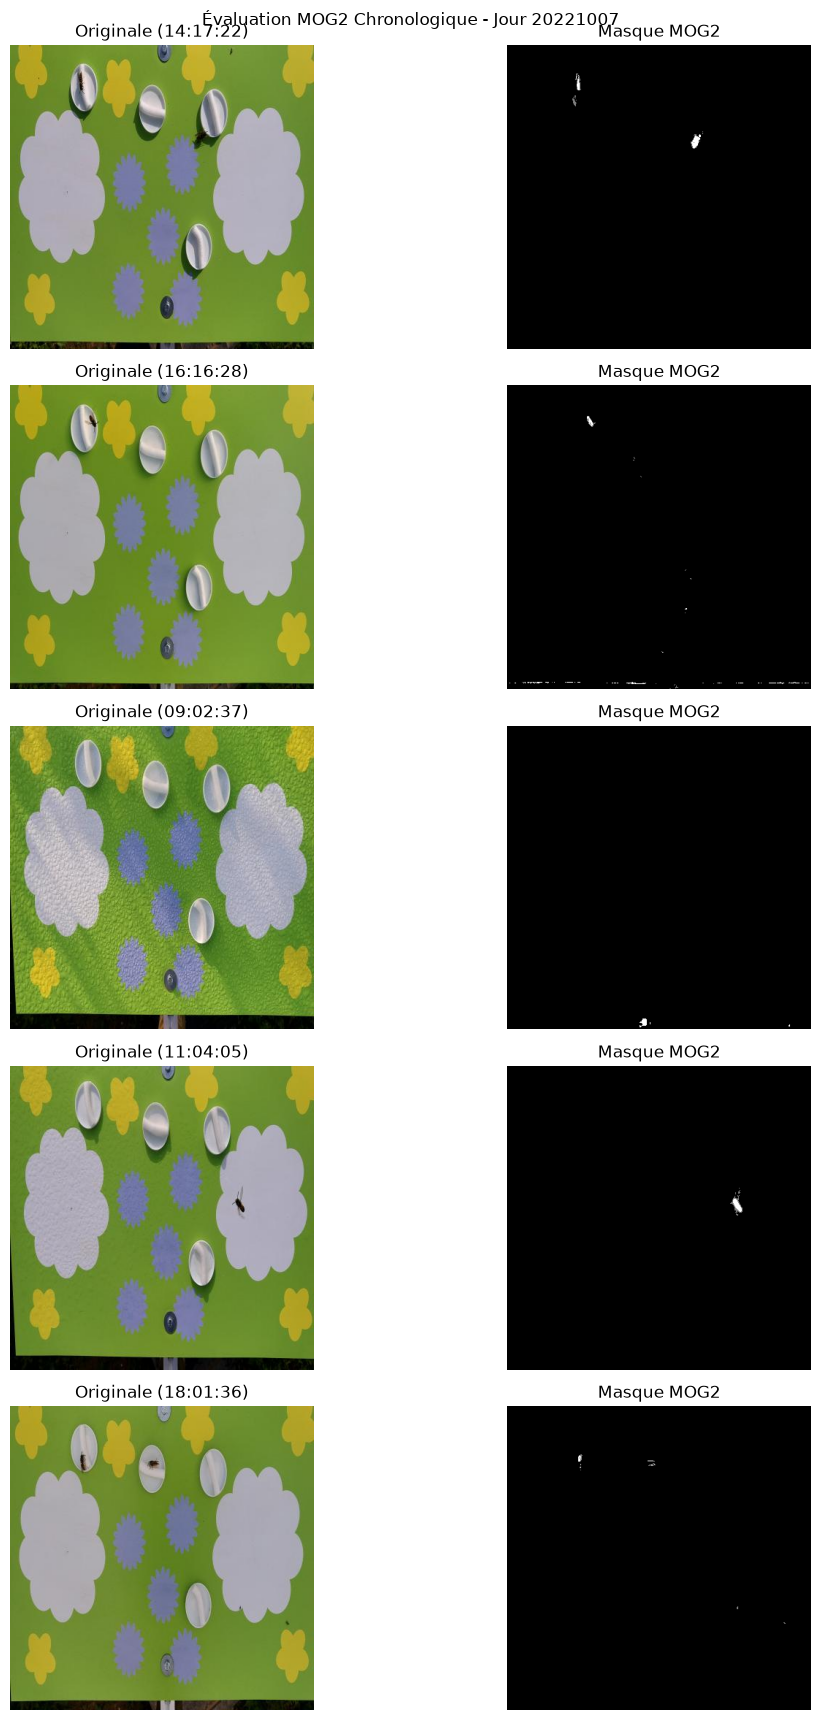


TRAITEMENT DE LA JOURNÉE : 20221012


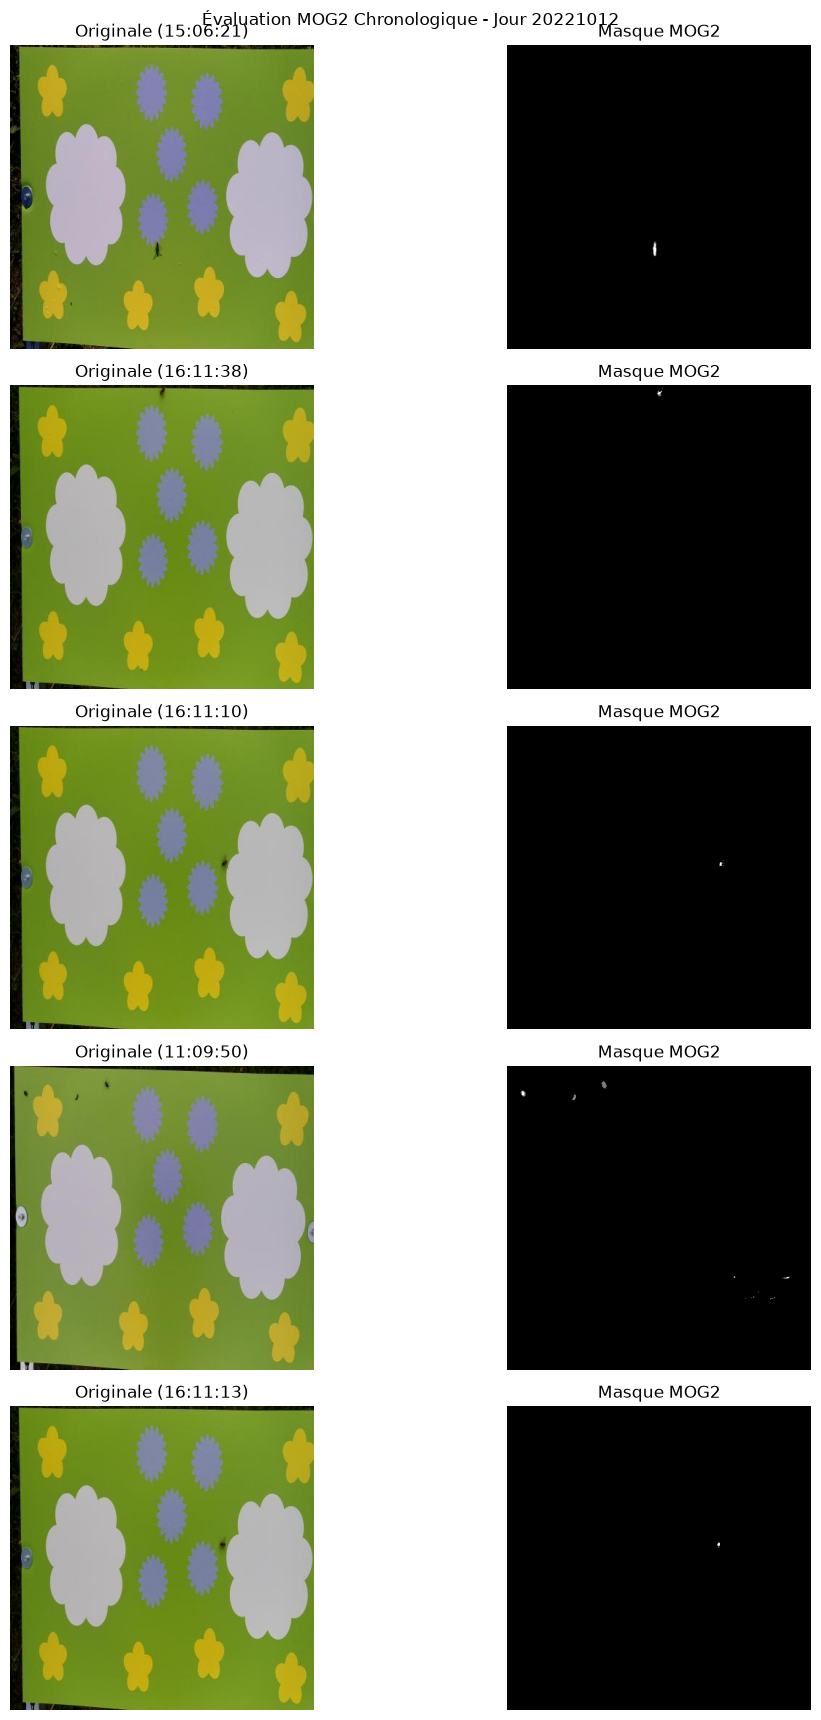


TRAITEMENT DE LA JOURNÉE : 20221017


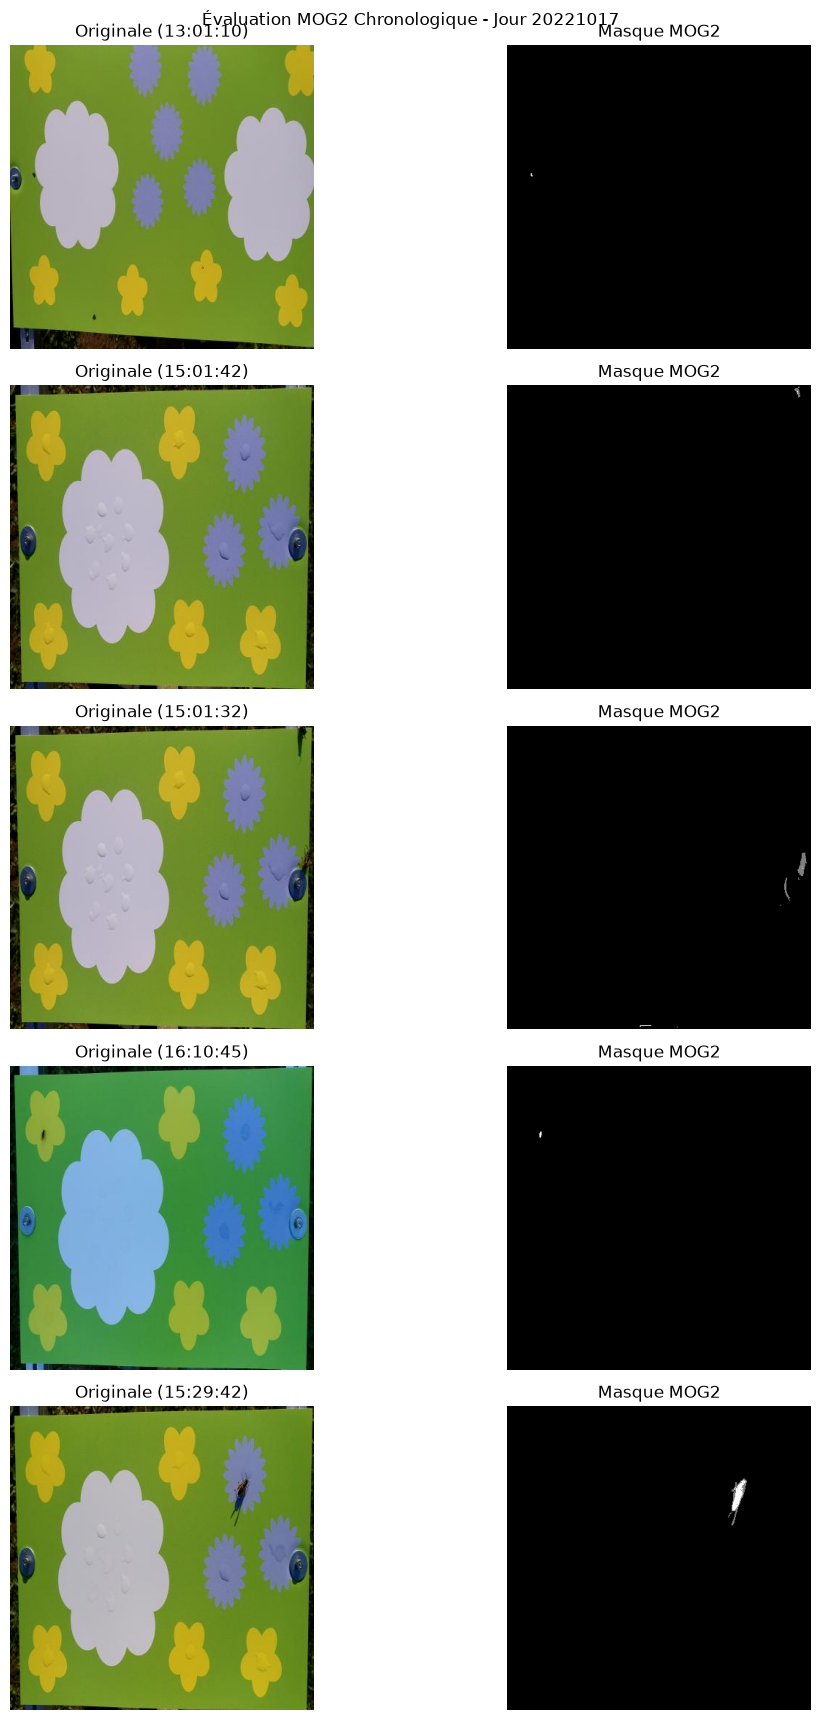

In [7]:
# On garde 8 images par jour
n_samples = 5 

for jour in jours_ajustement:
    print(f"\n{'='*40}")
    print(f"TRAITEMENT DE LA JOURNÉE : {jour}")
    print(f"{'='*40}")
    
    # Extraction des masques avec tes paramètres optimisés
    resultats_mog2 = apply_mog2_chronological_tuned(
        df_ajustement, 
        jour, 
        history=15, 
        var_threshold=100, 
        learning_rate=0.05
    )
    
    # Sélection aléatoire de 5 images
    echantillon = random.sample(resultats_mog2, min(n_samples, len(resultats_mog2)))
    
    # Affichage en grille : 5 lignes, 2 colonnes (oiginale vs masque)
    fig, axes = plt.subplots(len(echantillon), 2, figsize=(12, 3.5 * len(echantillon)))
    fig.suptitle(f"Évaluation MOG2 Chronologique - Jour {jour}", fontsize=12)
    
    for i, res in enumerate(echantillon):
        heure = res['image_name'][9:17].replace('-', ':')
        
        # 1. Originale
        axes[i, 0].imshow(cv2.cvtColor(res['original'], cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title(f"Originale ({heure})")
        axes[i, 0].axis('off')
        
        # 2. Masque Brut (qui est suffisamment net)
        axes[i, 1].imshow(res['mask_raw'], cmap='gray')
        axes[i, 1].set_title("Masque MOG2")
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    plt.show()

### Comptage / clustering sur les masques de chaque image

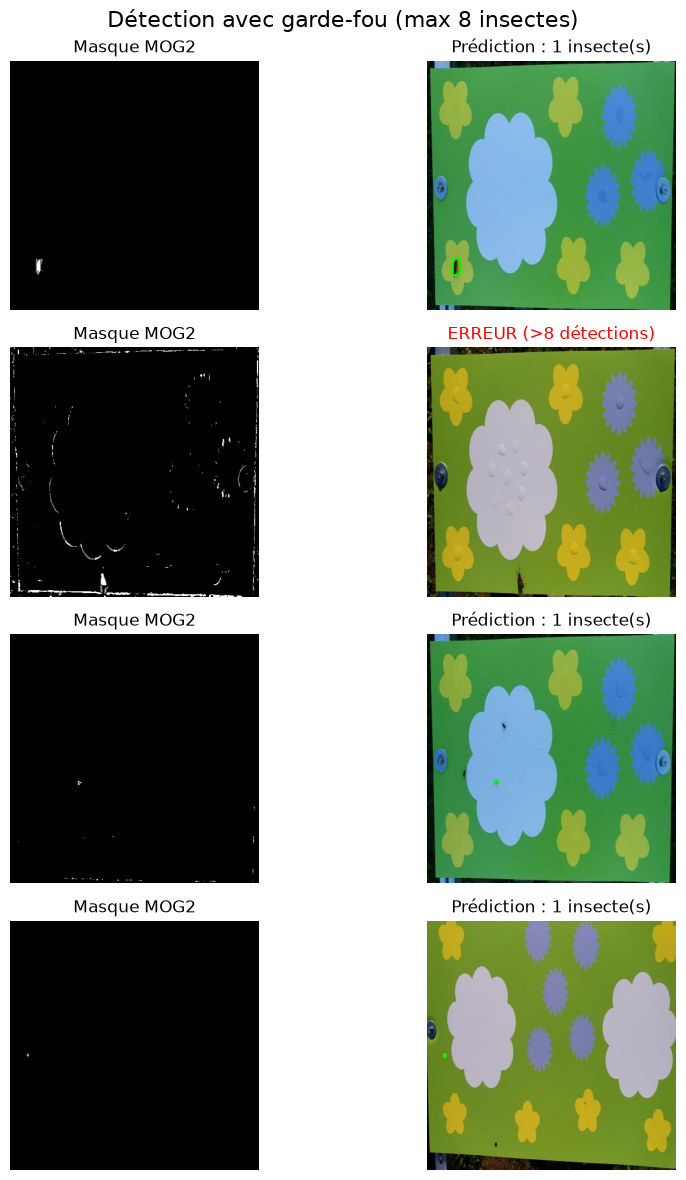

In [8]:
def count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8):
    """
    Extrait le nombre d'insectes. La tâche sur le masque peut faire au minimum 5 pixels et au maximum 700. Si le nombre dépasse max_detections, 
    renvoie une erreur et annule les détections.
    """
    _, binary = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    valid_boxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if min_area <= area <= max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            valid_boxes.append((x, y, w, h))
            
    nb_pred = len(valid_boxes)
    is_error = False
    
    # Le garde-fou : on considère l'image comme illisible/aberrante
    if nb_pred > max_detections:
        is_error = True
        nb_pred = 0
        valid_boxes = [] # On efface les boîtes aberrantes
        
    return nb_pred, valid_boxes, is_error

# Visualisation sur 4 images aléatoires
echantillon_4 = random.sample(resultats_mog2, min(4, len(resultats_mog2)))

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
fig.suptitle("Détection avec garde-fou (max 8 insectes)", fontsize=16)

for i, res in enumerate(echantillon_4):
    mask = res['mask_raw']
    img_visu = res['original'].copy()
    
    nb_pred, boxes, is_error = count_insects_from_mask(mask, min_area=5, max_area=700, max_detections=8)
    
    for (x, y, w, h) in boxes:
        cv2.rectangle(img_visu, (x, y), (x+w, y+h), (0, 255, 0), 2)
        
    axes[i, 0].imshow(mask, cmap='gray')
    axes[i, 0].set_title("Masque MOG2")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(cv2.cvtColor(img_visu, cv2.COLOR_BGR2RGB))
    # Affichage spécifique si l'image est en erreur
    titre = "ERREUR (>8 détections)" if is_error else f"Prédiction : {nb_pred} insecte(s)"
    couleur_titre = 'red' if is_error else 'black'
    axes[i, 1].set_title(titre, color=couleur_titre)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

### Optimisation des paramètres (GridSearch) sur le jeu d'ajustement. 
### Objectif : atteindre le plus faible écart pour chaque jour entre nombre réel et nombre prédit d'insecte

In [9]:
import numpy as np
import pandas as pd
import itertools

def evaluate_mog2_params(df_day: pd.DataFrame, var_thresh: float, lr: float):
    """Fonction permettant l'évaluation de l'erreur associée à une combinaison de paramètres pour l'application d'un MOG2 sur une journée d'ajustement"""
    df_day = df_day.sort_values("image_name")
    backSub = cv2.createBackgroundSubtractorMOG2(history=15, varThreshold=var_thresh, detectShadows=True)
    
    erreurs_absolues = []
    rejets = 0
    
    for _, row in df_day.iterrows():
        img = cv2.imread(row['image_path'])
        if img is None: 
            continue
            
        img_blur = cv2.GaussianBlur(img, (5, 5), 0)
        mask_raw = backSub.apply(img_blur, learningRate=lr)
        
        nb_pred, _, is_error = count_insects_from_mask(mask_raw, min_area=5, max_area=700, max_detections=8)
        
        # Gestion du garde-fou
        if is_error:
            rejets += 1
            continue # On ne calcule pas la MAE sur une image considérée comme crashée
            
        nb_vrai = row['insect_count']
        erreurs_absolues.append(abs(nb_pred - nb_vrai))
        
    # S'il n'y a eu que des rejets, on renvoie une MAE infinie
    mae = np.mean(erreurs_absolues) if erreurs_absolues else float('inf')
    return mae, rejets

# Configuration du GridSearch
learning_rates = [0.01, 0.05, 0.1, 0.2]
var_thresholds = [16, 30, 50, 100]
combinaisons = list(itertools.product(var_thresholds, learning_rates))

# Stats réelles
print(f"{'Jour':<10} | {'Stats réelles (min/max/moy)':<28} | {'varThresh':<10} | {'LR':<6} | {'MAE':<6} | {'Rejets'}")
print("-" * 85)

resultats_globaux = []

for jour in jours_ajustement:
    df_jour = df_ajustement[df_ajustement['jour'] == jour]

    # Extraction des statistiques réelles du jour
    min_reel = df_jour['insect_count'].min()
    max_reel = df_jour['insect_count'].max()
    moy_reel = df_jour['insect_count'].mean()
    stats_str = f"{min_reel} / {max_reel} / {moy_reel:.2f}"

    meilleure_mae = float('inf')
    meilleurs_params = None
    rejets_associes = 0
    
    for var_thresh, lr in combinaisons:
        mae, rejets = evaluate_mog2_params(df_jour, var_thresh, lr)
        
        if mae < meilleure_mae:
            meilleure_mae = mae
            meilleurs_params = (var_thresh, lr)
            rejets_associes = rejets
            
    resultats_globaux.append({
        'jour': jour,
        'var_threshold': meilleurs_params[0],
        'learning_rate': meilleurs_params[1],
        'mae': meilleure_mae
    })
    
    # Affichage de la ligne avec le contexte réel
    print(f"{jour:<10} | {stats_str:<28} | {meilleurs_params[0]:<10} | {meilleurs_params[1]:<6} | {meilleure_mae:.3f} | {rejets_associes}/{len(df_jour)}")

df_resultats = pd.DataFrame(resultats_globaux)
print("\n=== Paramètres médians à retenir ===")
print(f"varThreshold : {df_resultats['var_threshold'].median()}")
print(f"learningRate : {df_resultats['learning_rate'].median()}")

Jour       | Stats réelles (min/max/moy)  | varThresh  | LR     | MAE    | Rejets
-------------------------------------------------------------------------------------
20221006   | 0 / 5 / 1.62                 | 100        | 0.05   | 0.586 | 14/386
20221007   | 0 / 4 / 2.44                 | 100        | 0.2    | 0.785 | 7/114
20221012   | 0 / 2 / 1.00                 | 30         | 0.01   | 0.093 | 41/95
20221017   | 0 / 4 / 1.68                 | 100        | 0.05   | 0.469 | 11/107

=== Paramètres médians à retenir ===
varThreshold : 100.0
learningRate : 0.05
